##### Import Necessary Library


In [29]:
import tensorflow as tf
from keras.layers import Conv2D, ZeroPadding2D, Activation, Input, Dropout, Add
from keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.layers import LayerNormalization
from keras.layers import BatchNormalization
from keras.layers import MaxPooling2D, AveragePooling2D
from keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
#from keras.initializers import glorot_uniform
from keras import backend as K

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

#### Check GPU Status


In [30]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))

Num GPUs Available:  1


In [31]:
import cv2
import os


def load_images(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (80, 80))
            images.append(img)

    return np.array(images)

In [32]:
mal_aca = load_images("colon_image_sets/colon_aca")
benign = load_images("colon_image_sets/colon_n")

In [33]:
print(
    f"Number of images for every class: BENIGN {benign.shape[0]}, ADENOCARCINOMAS {mal_aca.shape[0]}."
)
print(f"Images shape: {benign[0].shape}.")

Number of images for every class: BENIGN 5000, ADENOCARCINOMAS 5000.
Images shape: (80, 80, 3).


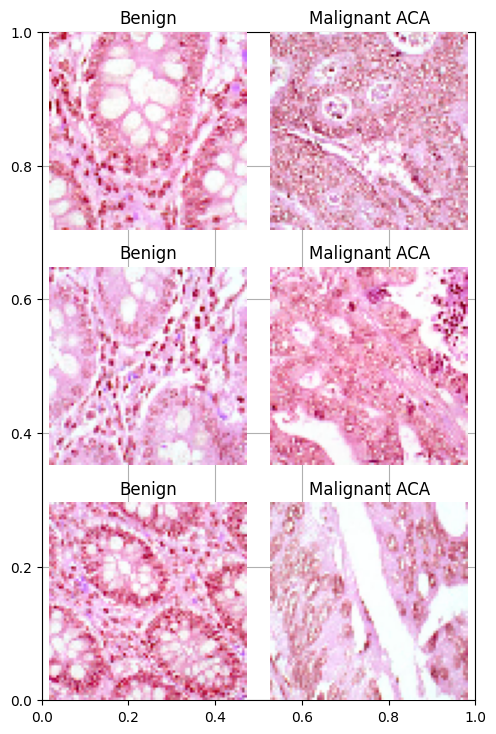

In [34]:
indices = [0, 40, 2300]

plt.figure(figsize=(5, 2.5 * len(indices)))
plt.grid(None)

for n, idx in enumerate(indices):
    plt.subplot(len(indices), 2, 2 * n + 1)
    plt.imshow(benign[idx])
    plt.title("Benign")
    plt.axis("off")

    plt.subplot(len(indices), 2, 2 * n + 2)
    plt.imshow(mal_aca[idx])
    plt.title("Malignant ACA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
samples = np.concatenate((benign, mal_aca))
labels = np.array(benign.shape[0] * [0] + mal_aca.shape[0] * [1])

In [36]:
print(f"Samples shape check: {samples.shape}.")
print(f"Labels shape check: {labels.shape}.")

Samples shape check: (10000, 80, 80, 3).
Labels shape check: (10000,).


# BASE MODEL


In [37]:
indices = np.arange(samples.shape[0])
np.random.shuffle(indices)

samples = samples[indices]
labels = labels[indices]

# normalize pictures
samples = samples.astype("float32") / 255

In [38]:
import sklearn as sk
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(samples, labels, test_size=0.2)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

In [39]:
Y_train = to_categorical(y_train, 3)
Y_val = to_categorical(y_val, 3)
Y_test = to_categorical(y_test, 3)

print(Y_train[0])
print(f"Y_train shape after one hot encoding: {Y_val.shape}")
print(f"Y_train shape after one hot encoding: {X_val.shape}")

[1. 0. 0.]
Y_train shape after one hot encoding: (1000, 3)
Y_train shape after one hot encoding: (1000, 80, 80, 3)


In [40]:
def base_model(input_shape=(80, 80, 3), classes=3):
    inputs = Input(shape=input_shape)

    X = Conv2D(32, 3, 3, activation="relu")(inputs)
    X = MaxPooling2D(pool_size=(2, 2))(X)

    X = Conv2D(64, 3, 3, activation="relu")(X)
    X = MaxPooling2D(pool_size=(2, 2))(X)
    X = Dropout(0.2)(X)

    X = Conv2D(128, 3, 3, activation="relu", padding="same")(X)
    X = MaxPooling2D(pool_size=(2, 2), padding="same")(X)
    X = Dropout(0.2)(X)

    X = Flatten()(X)
    X = Dense(256, activation="relu")(X)
    outputs = Dense(classes, activation="softmax")(X)

    model = Model(inputs, outputs)

    return model

In [41]:
model = base_model(input_shape=(80, 80, 3), classes=3)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,043 (496.26 KB)

 Trainable params: 127,043 (496.26 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [43]:
history = model.fit(
    X_train, Y_train, batch_size=64, epochs=25, validation_data=(X_val, Y_val)
)

2024-09-18 00:20:19.931658: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.
2024-09-18 00:20:20.480796: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/25


I0000 00:00:1726597222.121681   20719 service.cc:146] XLA service 0x73bf5c001f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1726597222.121733   20719 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce GTX 1660, Compute Capability 7.5
2024-09-18 00:20:22.193262: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-09-18 00:20:22.463497: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


 31/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4254 - loss: 0.8608  

I0000 00:00:1726597225.912547   20719 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


118/125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4678 - loss: 0.7651

2024-09-18 00:20:26.638201: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 76800000 exceeds 10% of free system memory.
2024-09-18 00:20:26.707253: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 76800000 exceeds 10% of free system memory.


125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4702 - loss: 0.7618 - val_accuracy: 0.5740 - val_loss: 0.6634
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6851 - loss: 0.5872 - val_accuracy: 0.7960 - val_loss: 0.4343
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8006 - loss: 0.4189 - val_accuracy: 0.7360 - val_loss: 0.4983
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8279 - loss: 0.3818 - val_accuracy: 0.8590 - val_loss: 0.3520
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8324 - loss: 0.3733 - val_accuracy: 0.8640 - val_loss: 0.3258
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8670 - loss: 0.3148 - val_accuracy: 0.8960 - val_loss: 0.2667
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8937 - loss: 0.2647 - val_accuracy: 0.9050 - val_loss: 0.2432
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8899 - loss: 0.2686 - val_accuracy: 0.8940 - val

In [51]:
import matplotlib.pyplot as plt

print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


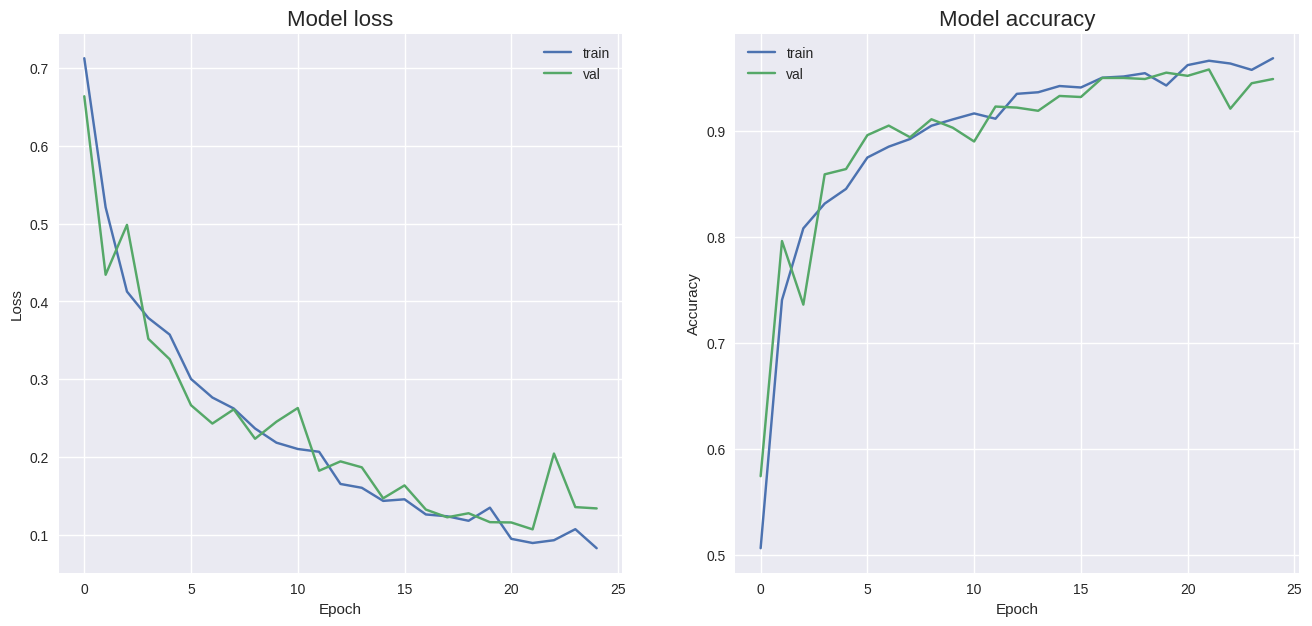

In [52]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss", fontsize=16)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy", fontsize=16)
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.show()

## Wrogly Classified Samples


In [54]:
y_pred_test = model.predict(X_test, verbose=1)
y_pred_train = model.predict(X_train, verbose=1)

2024-09-18 00:31:23.969253: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 76800000 exceeds 10% of free system memory.


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Wrongly classified samples


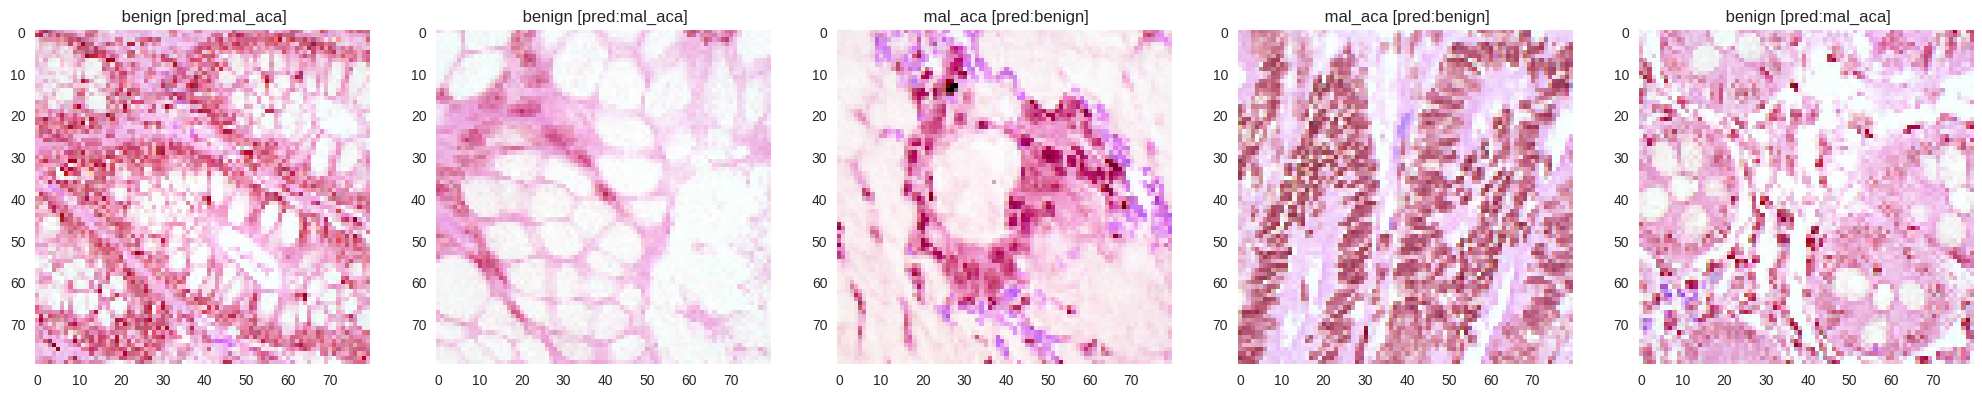

In [59]:
y_train_labels = np.argmax(Y_train, axis=1)
label_names = ["benign", "mal_aca"]
y_pred_train_labels = np.argmax(y_pred_train, axis=1)
mistakes = np.where(y_pred_train_labels != y_train_labels)[0]

n = 5

plt.figure(figsize=(5 * n, 5))

# get 5 random false negatives
print("Wrongly classified samples")
for i, val in enumerate(np.random.choice(mistakes, n)):

    plt.subplot(1, n, i + 1)
    plt.imshow(X_train[val])
    plt.title(
        f" {label_names[y_train_labels[val]]} [pred:{label_names[y_pred_train_labels[val]]}]",
        fontsize=12,
    )
    plt.grid(None)

## Explain Prediction Using Lime


In [64]:
from lime import lime_image
from PIL import Image
from skimage.segmentation import mark_boundaries


def xAI(model, img_dir):
    image = Image.open(img_dir)
    image = image.resize((80, 80))
    img = np.asarray(image)
    img = img / 255
    img2 = np.zeros((img.shape[0], img.shape[1], 3))
    img2[:, :, :] = img  # same value in each channel
    print(img2.shape)
    explainer = lime_image.LimeImageExplainer(random_state=42)

    explanation = explainer.explain_instance(
        img2,
        model.predict,
        labels=["benign", "mal_aca"],
        top_labels=2,
        hide_color=0,
        num_samples=1000,
    )
    image, mask = explanation.get_image_and_mask(
        model.predict(img2.reshape((1, 80, 80, 3))).argmax(axis=1)[0],
        positive_only=False,
        hide_rest=False,
    )
    plt.imshow(mark_boundaries(image, mask))

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


  2%|▏         | 20/1000 [00:00<00:07, 133.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


 98%|█████████▊| 980/1000 [00:06<00:00, 154.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


100%|██████████| 1000/1000 [00:06<00:00, 153.74it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


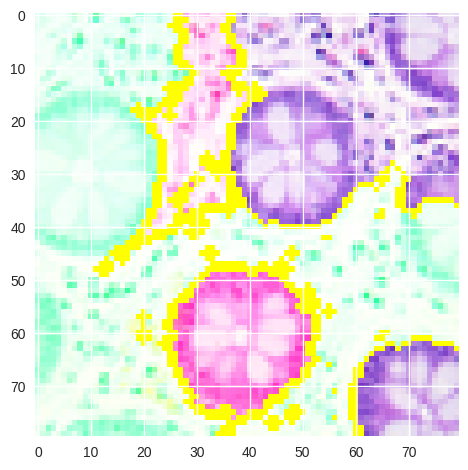

In [67]:
xAI(model, "colon_image_sets/colon_n/colonn5.jpeg")

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


  2%|▏         | 20/1000 [00:00<00:07, 128.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


 99%|█████████▉| 990/1000 [00:06<00:00, 152.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


100%|██████████| 1000/1000 [00:06<00:00, 149.37it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


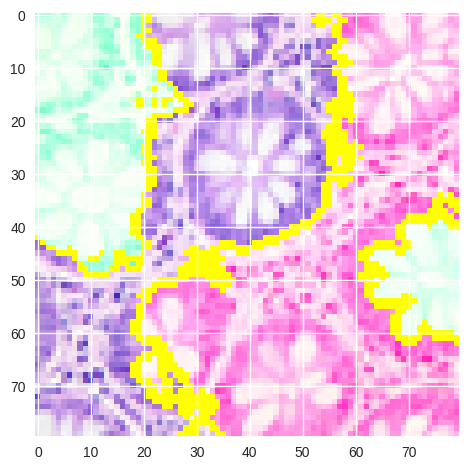

In [68]:
xAI(model, "colon_image_sets/colon_n/colonn3725.jpeg")

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


  2%|▏         | 20/1000 [00:00<00:07, 135.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


 98%|█████████▊| 980/1000 [00:06<00:00, 162.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


100%|██████████| 1000/1000 [00:06<00:00, 152.71it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


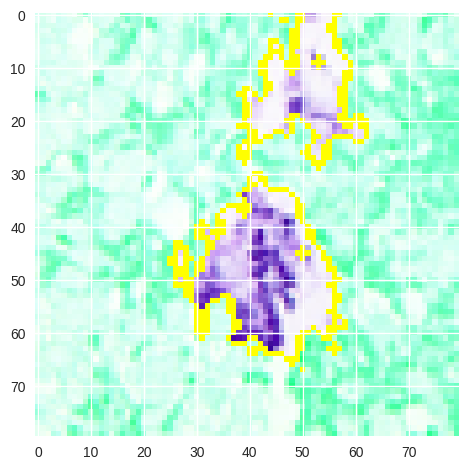

In [69]:
xAI(model, "colon_image_sets/colon_aca/colonca4175.jpeg")

# VGG16


In [70]:
def base_model(input_shape=(80, 80, 3), classes=3):
    inputs = Input(shape=input_shape)

    X = Conv2D(32, 3, 3, activation="relu")(inputs)
    X = MaxPooling2D(pool_size=(2, 2))(X)

    X = Conv2D(64, 3, 3, activation="relu")(X)
    X = MaxPooling2D(pool_size=(2, 2))(X)
    X = Dropout(0.2)(X)

    X = Conv2D(128, 3, 3, activation="relu", padding="same")(X)
    X = MaxPooling2D(pool_size=(2, 2), padding="same")(X)
    X = Dropout(0.2)(X)

    X = Flatten()(X)
    X = Dense(256, activation="relu")(X)
    outputs = Dense(classes, activation="softmax")(X)

    model = Model(inputs, outputs)

    return model

In [71]:
model = base_model(input_shape=(80, 80, 3), classes=3)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,043 (496.26 KB)

 Trainable params: 127,043 (496.26 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics="accuracy")

In [74]:
history = model.fit(
    X_train, Y_train, batch_size=64, epochs=100, validation_data=(X_val, Y_val)
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4881 - loss: 0.7631 - val_accuracy: 0.5010 - val_loss: 0.6826
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5879 - loss: 0.6528 - val_accuracy: 0.8120 - val_loss: 0.4151
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7838 - loss: 0.4545 - val_accuracy: 0.7870 - val_loss: 0.4535
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8277 - loss: 0.3841 - val_accuracy: 0.8210 - val_loss: 0.3845
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8446 - loss: 0.3580 - val_accuracy: 0.8470 - val_loss: 0.3578
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8547 - loss: 0.3352 - val_accuracy: 0.8320 - val_loss: 0.3597
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8683 - loss: 0.3173 - val_accuracy: 0.8420 - val_loss: 0.3771
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8873 - loss: 0.2710 - val_acc

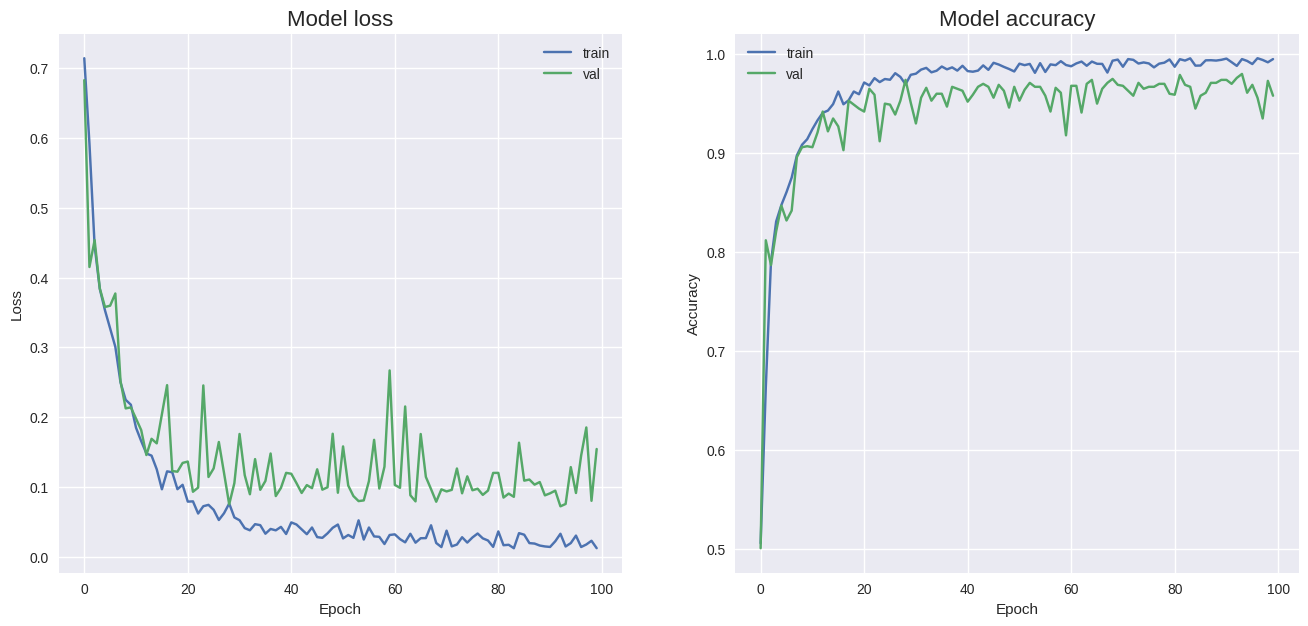

In [76]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss", fontsize=16)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy", fontsize=16)
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.show()

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sn

In [78]:
y_pred_test = model.predict(X_test, verbose=1)
y_pred_train = model.predict(X_train, verbose=1)

# conversion to one hot encoding
# y_pred_test = (y_pred_test > 0.5).astype("int32")
# y_pred_train = (y_pred_train > 0.5).astype("int32")

# convert it to numerical classes
y_pred_test = np.argmax(y_pred_test, axis=1)
y_pred_train = np.argmax(y_pred_train, axis=1)

score_test = model.evaluate(X_test, Y_test)
print(f"Train accuracy: {history.history['accuracy'][-1]:.3f}")
print(f"Validation accuracy: {history.history['val_accuracy'][-1]:.3f}")
print(f"Test accuracy: {score_test[1]:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9574 - loss: 0.1568
Train accuracy: 0.995
Validation accuracy: 0.958
Test accuracy: 0.964


<Axes: >

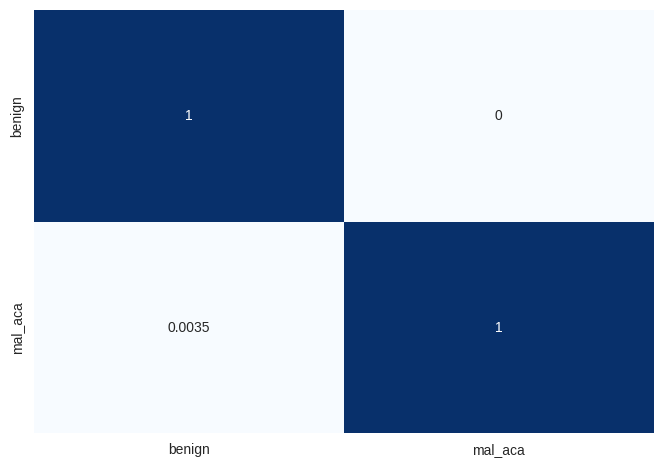

In [80]:
label_names = ["benign", "mal_aca"]
confmat = confusion_matrix(y_train, y_pred_train, normalize="true")
sn.heatmap(
    confmat,
    annot=True,
    cmap="Blues",
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
)

# Wrongly classified samples


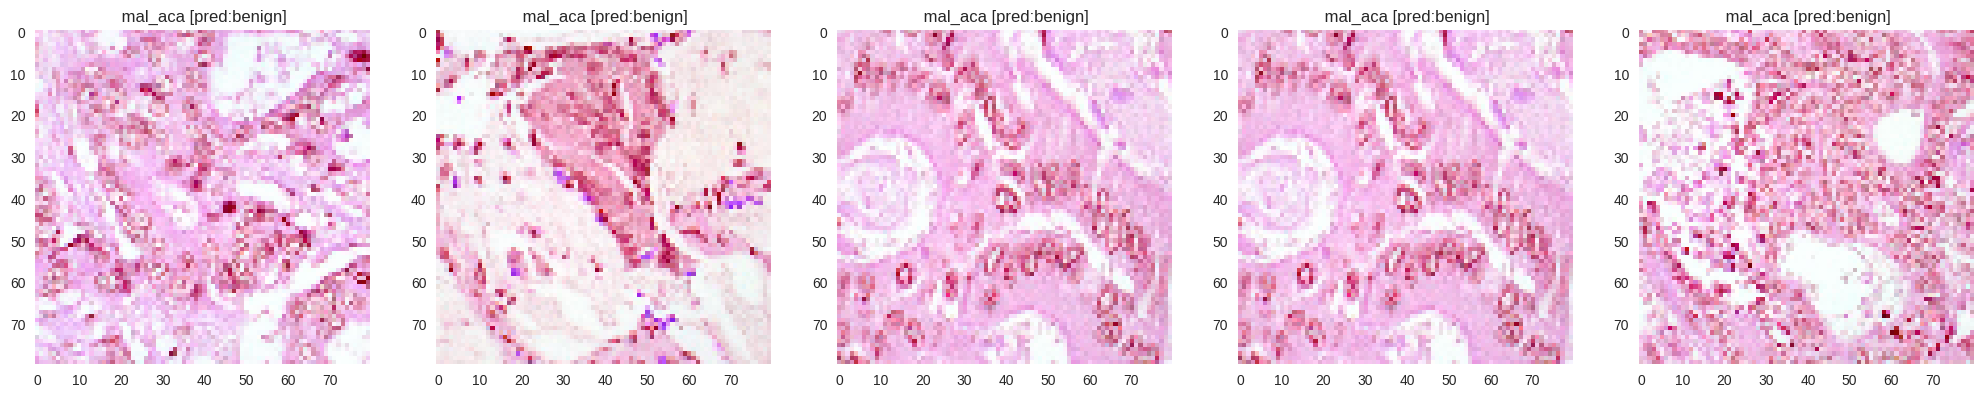

In [81]:
mistakes = np.where(y_pred_train != y_train)[0]

n = 5

plt.figure(figsize=(5 * n, 5))

# get 5 random false negatives
for i, val in enumerate(np.random.choice(mistakes, n)):

    plt.subplot(1, n, i + 1)
    plt.imshow(X_train[val])
    plt.title(
        f" {label_names[y_train[val]]} [pred:{label_names[y_pred_train[val]]}]",
        fontsize=12,
    )
    plt.grid(None)

## Explain Prediction Using Lime


In [82]:
from lime import lime_image
from PIL import Image
from skimage.segmentation import mark_boundaries


def xAI(model, img_dir):
    image = Image.open(img_dir)
    image = image.resize((80, 80))
    img = np.asarray(image)
    img = img / 255
    img2 = np.zeros((img.shape[0], img.shape[1], 3))
    img2[:, :, :] = img  # same value in each channel
    print(img2.shape)
    explainer = lime_image.LimeImageExplainer(random_state=42)

    explanation = explainer.explain_instance(
        img2,
        model.predict,
        labels=["benign", "mal_aca"],
        top_labels=2,
        hide_color=0,
        num_samples=1000,
    )
    image, mask = explanation.get_image_and_mask(
        model.predict(img2.reshape((1, 80, 80, 3))).argmax(axis=1)[0],
        positive_only=False,
        hide_rest=False,
    )
    plt.imshow(mark_boundaries(image, mask))

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 10/1000 [00:00<00:17, 55.83it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


 99%|█████████▉| 990/1000 [00:06<00:00, 155.53it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


100%|██████████| 1000/1000 [00:06<00:00, 154.03it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


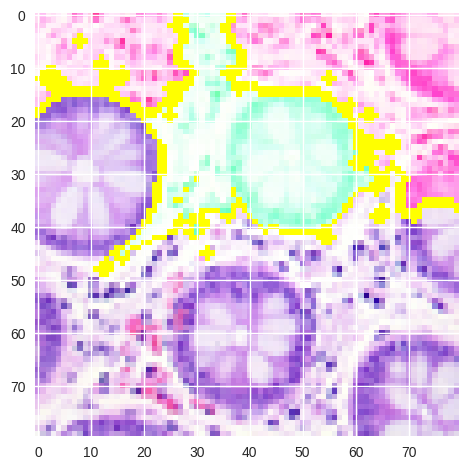

In [83]:
xAI(model, "colon_image_sets/colon_n/colonn5.jpeg")

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


  2%|▏         | 20/1000 [00:00<00:07, 137.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


 98%|█████████▊| 980/1000 [00:06<00:00, 153.43it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


100%|██████████| 1000/1000 [00:06<00:00, 152.63it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


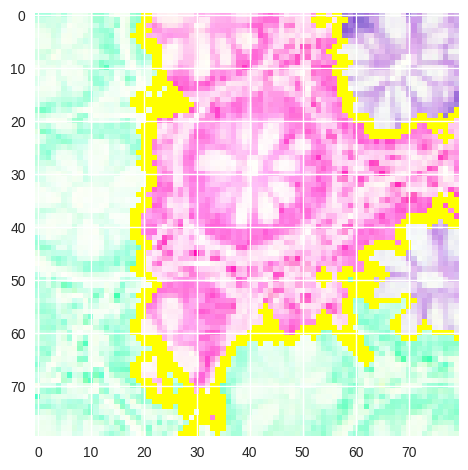

In [84]:
xAI(model, "colon_image_sets/colon_n/colonn3725.jpeg")

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


  2%|▏         | 20/1000 [00:00<00:08, 111.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


 98%|█████████▊| 980/1000 [00:06<00:00, 146.83it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


100%|██████████| 1000/1000 [00:06<00:00, 144.89it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


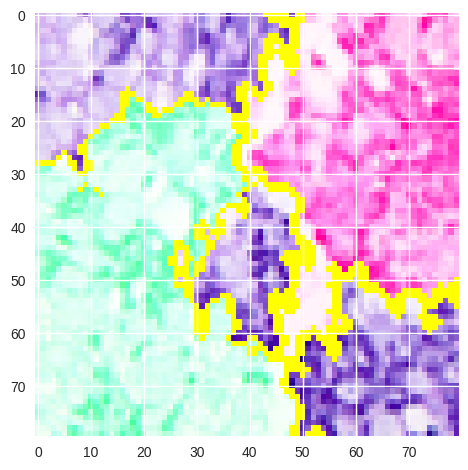

In [85]:
xAI(model, "colon_image_sets/colon_aca/colonca4175.jpeg")

# ResNet50


In [86]:
def identity_block(X, f, filters, stage, block):
    """
    Implementation of the identity block

    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network

    """

    # defining name basis
    conv_name_base = "res" + str(stage) + block + "_branch"
    bn_name_base = "bn" + str(stage) + block + "_branch"

    F1, F2, F3 = filters

    X_shortcut = X

    X = Conv2D(
        filters=F1,
        kernel_size=(1, 1),
        strides=(1, 1),
        padding="valid",
        name=conv_name_base + "2a",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2a")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        filters=F2,
        kernel_size=(f, f),
        strides=(1, 1),
        padding="same",
        name=conv_name_base + "2b",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2b")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        filters=F3,
        kernel_size=(1, 1),
        strides=(1, 1),
        padding="valid",
        name=conv_name_base + "2c",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2c")(X)

    X = Add()([X, X_shortcut])
    X = Activation("relu")(X)

    return X

In [87]:
def convolutional_block(X, f, filters, stage, block, s=2):
    """
    Implementation of the convolutional block

    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    s -- Integer, specifying the stride to be used

    """

    # defining name basis
    conv_name_base = "res" + str(stage) + block + "_branch"
    bn_name_base = "bn" + str(stage) + block + "_branch"

    F1, F2, F3 = filters

    X_shortcut = X

    X = Conv2D(
        F1,
        (1, 1),
        strides=(s, s),
        name=conv_name_base + "2a",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2a")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        F2,
        (f, f),
        strides=(1, 1),
        padding="same",
        name=conv_name_base + "2b",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2b")(X)
    X = Activation("relu")(X)

    X = Conv2D(
        F3,
        (1, 1),
        strides=(1, 1),
        padding="valid",
        name=conv_name_base + "2c",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name=bn_name_base + "2c")(X)

    X_shortcut = Conv2D(
        F3,
        (1, 1),
        strides=(s, s),
        padding="valid",
        name=conv_name_base + "1",
        kernel_initializer=glorot_uniform(seed=0),
    )(X_shortcut)
    X_shortcut = BatchNormalization(axis=3, name=bn_name_base + "1")(X_shortcut)

    X = Add()([X, X_shortcut])
    X = Activation("relu")(X)

    return X

In [88]:
def ResNet50(input_shape=(80, 80, 3), classes=3):
    """
    Implementation of the popular ResNet50 the following architecture:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER

    """

    X_input = Input(input_shape)

    X = ZeroPadding2D((3, 3))(X_input)

    X = Conv2D(
        64,
        (7, 7),
        strides=(2, 2),
        name="conv1",
        kernel_initializer=glorot_uniform(seed=0),
    )(X)
    X = BatchNormalization(axis=3, name="bn_conv1")(X)
    X = Activation("relu")(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    X = convolutional_block(X, f=3, filters=[64, 64, 256], stage=2, block="a", s=1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block="b")
    X = identity_block(X, 3, [64, 64, 256], stage=2, block="c")

    X = convolutional_block(X, 3, [128, 128, 512], stage=3, s=2, block="a")
    X = identity_block(X, 3, [128, 128, 512], stage=3, block="b")
    X = identity_block(X, 3, [128, 128, 512], stage=3, block="c")
    X = identity_block(X, 3, [128, 128, 512], stage=3, block="d")

    X = convolutional_block(X, 3, [256, 256, 1024], stage=4, s=2, block="a")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="b")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="c")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="d")
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block="e")

    X = convolutional_block(X, 3, [512, 512, 2048], stage=5, s=2, block="a")
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block="b")
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block="c")

    X = AveragePooling2D(pool_size=(2, 2), name="avg_pool")(X)

    # output layer
    X = Flatten()(X)
    X = Dense(
        classes,
        activation="softmax",
        name="fc" + str(classes),
        kernel_initializer=glorot_uniform(seed=0),
    )(X)

    # Create model
    model = Model(inputs=X_input, outputs=X, name="ResNet50")

    return model

In [89]:
from keras.initializers import glorot_uniform

resmodel = ResNet50(input_shape=(80, 80, 3), classes=3)

In [90]:
resmodel.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 80, 80, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 86, 86, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 40, 40,    │      9,472 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 40, 40,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 40, 40,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 19, 19,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2a      │ (None, 19, 19,    │      4,160 │ max_pooling2d_9[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2a       │ (None, 19, 19,    │        256 │ res2a_branch2a[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 19, 19,    │          0 │ bn2a_branch2a[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2b      │ (None, 19, 19,    │     36,928 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2b       │ (None, 19, 19,    │        256 │ res2a_branch2b[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 19, 19,    │          0 │ bn2a_branch2b[0]… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch2c      │ (None, 19, 19,    │     16,640 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_branch1       │ (None, 19, 19,    │     16,640 │ max_pooling2d_9[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch2c       │ (None, 19, 19,    │      1,024 │ res2a_branch2c[0… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_branch1        │ (None, 19, 19,    │      1,024 │ res2a_branch1[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 19, 19,    │          0 │ bn2a_branch2c[0]

 Total params: 22,472,067 (85.72 MB)

 Trainable params: 22,422,019 (85.53 MB)

 Non-trainable params: 50,048 (195.50 KB)

In [91]:
resmodel.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

In [92]:
resmodel.fit(X_train, Y_train, batch_size=64, epochs=10, validation_data=(X_val, Y_val))

Epoch 1/10


2024-09-18 01:18:40.482198: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 18.37GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-09-18 01:18:40.555451: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.61GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-09-18 01:18:40.922363: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.69GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 176ms/step - accuracy: 0.7676 - loss: 1.2529 - val_accuracy: 0.5010 - val_loss: 3.7335
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.9785 - loss: 0.0563 - val_accuracy: 0.5010 - val_loss: 7.9796
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.9906 - loss: 0.0301 - val_accuracy: 0.5010 - val_loss: 10.3042
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.9928 - loss: 0.0203 - val_accuracy: 0.7250 - val_loss: 1.6259
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.9965 - loss: 0.0091 - val_accuracy: 0.5010 - val_loss: 12.6362
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.9907 - loss: 0.0312 - val_accuracy: 0.5980 - val_loss: 26.2380
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.9876 - loss: 0.0355 - val_accuracy: 0.8580 - val_loss: 0.7946
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.9949 - loss: 0.0156 - 

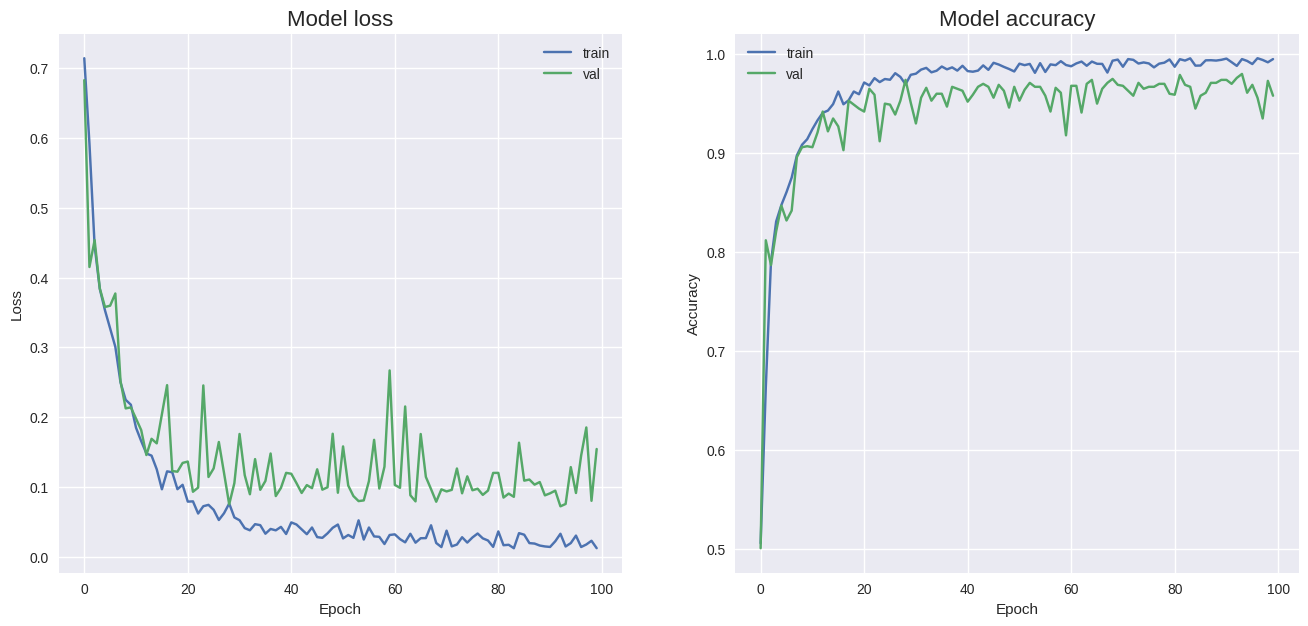

In [93]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss", fontsize=16)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy", fontsize=16)
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.show()

In [94]:
y_pred_test = model.predict(X_test, verbose=1)
y_pred_train = model.predict(X_train, verbose=1)

# conversion to one hot encoding
# y_pred_test = (y_pred_test > 0.5).astype("int32")
# y_pred_train = (y_pred_train > 0.5).astype("int32")

# convert it to numerical classes
y_pred_test = np.argmax(y_pred_test, axis=1)
y_pred_train = np.argmax(y_pred_train, axis=1)

score_test = model.evaluate(X_test, Y_test)
print(f"Train accuracy: {history.history['accuracy'][-1]:.3f}")
print(f"Validation accuracy: {history.history['val_accuracy'][-1]:.3f}")
print(f"Test accuracy: {score_test[1]:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9574 - loss: 0.1568
Train accuracy: 0.995
Validation accuracy: 0.958
Test accuracy: 0.964


<Axes: >

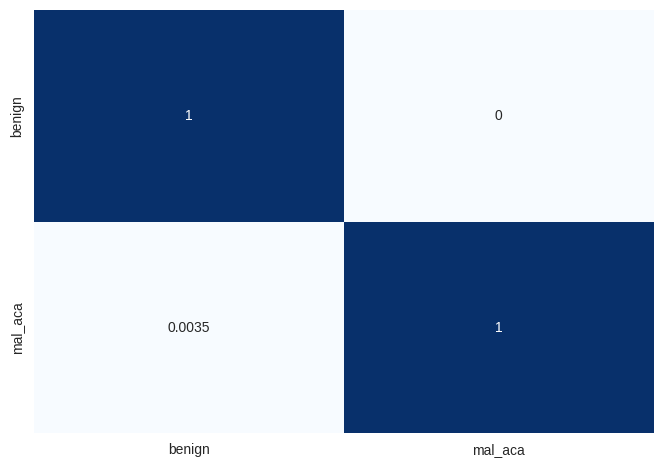

In [95]:
label_names = ["benign", "mal_aca"]
confmat = confusion_matrix(y_train, y_pred_train, normalize="true")
sn.heatmap(
    confmat,
    annot=True,
    cmap="Blues",
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
)

## Explain Prediction Using Lime


In [96]:
from lime import lime_image
from PIL import Image
from skimage.segmentation import mark_boundaries


def xAI(model, img_dir):
    image = Image.open(img_dir)
    image = image.resize((80, 80))
    img = np.asarray(image)
    img = img / 255
    img2 = np.zeros((img.shape[0], img.shape[1], 3))
    img2[:, :, :] = img  # same value in each channel
    print(img2.shape)
    explainer = lime_image.LimeImageExplainer(random_state=42)

    explanation = explainer.explain_instance(
        img2,
        model.predict,
        labels=["benign", "mal_aca"],
        top_labels=2,
        hide_color=0,
        num_samples=1000,
    )
    image, mask = explanation.get_image_and_mask(
        model.predict(img2.reshape((1, 80, 80, 3))).argmax(axis=1)[0],
        positive_only=False,
        hide_rest=False,
    )
    plt.imshow(mark_boundaries(image, mask))

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


  2%|▏         | 20/1000 [00:00<00:07, 127.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


 98%|█████████▊| 980/1000 [00:06<00:00, 148.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


100%|██████████| 1000/1000 [00:06<00:00, 150.98it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


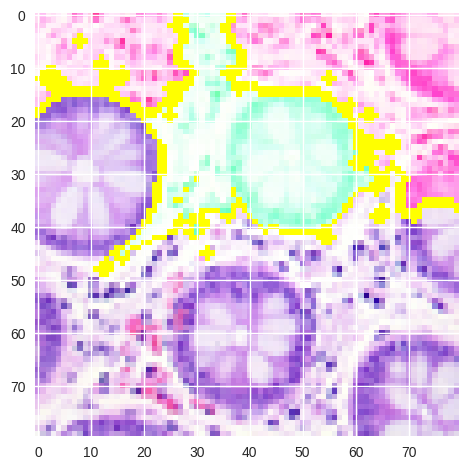

In [97]:
xAI(model, "colon_image_sets/colon_n/colonn5.jpeg")

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


  2%|▏         | 20/1000 [00:00<00:07, 131.47it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


 98%|█████████▊| 980/1000 [00:06<00:00, 162.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


100%|██████████| 1000/1000 [00:06<00:00, 153.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


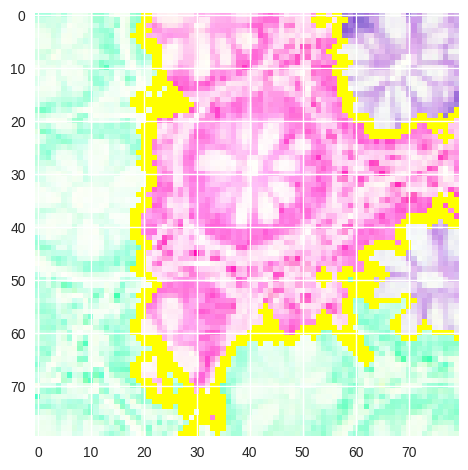

In [98]:
xAI(model, "colon_image_sets/colon_n/colonn3725.jpeg")

(80, 80, 3)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


  2%|▏         | 20/1000 [00:00<00:08, 112.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


 99%|█████████▉| 990/1000 [00:07<00:00, 157.47it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


100%|██████████| 1000/1000 [00:07<00:00, 136.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


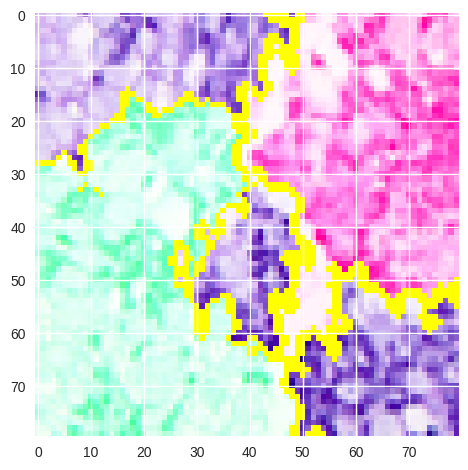

In [99]:
xAI(model, "colon_image_sets/colon_aca/colonca4175.jpeg")